# Netflix Movies and TV Shows Data Analysis

## Project Overview

This project analyzes the Netflix Movies and TV Shows dataset using Python, Pandas, and Matplotlib.

The objective of this project is to explore Netflix's content library and identify patterns related to content types, genres, countries, release years, ratings, directors, and actors.

The project demonstrates practical data analysis skills including data cleaning, filtering, grouping, aggregation, string manipulation, handling missing values, and data visualization.


In [ ]:
## 1. Import Libraries
import pandas as pd

## 2. Load Dataset
df = pd.read_csv("/content/netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
## 3. Understanding the Dataset
df.shape


(8807, 12)

In [ ]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(8807, 12)

In [ ]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
(df.isna().sum() / len(df) * 100).round(2)

,0
show_id,0.00
type,0.00
title,0.00
director,29.91
cast,9.37
country,9.44
date_added,0.11
release_year,0.00
rating,0.05
duration,0.03


In [ ]:
## 4. Data Cleaning

clean_df = df.copy()
clean_df["director"] = clean_df["director"].fillna("Unknown")
clean_df["cast"] = clean_df["cast"].fillna("Unknown")
clean_df["country"] = clean_df["country"].fillna("Unknown")
clean_df["date_added"] = clean_df["date_added"].fillna("Unknown")
clean_df["rating"] = clean_df["rating"].fillna("Unknown")
clean_df.isna().sum()


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,3


In [ ]:

clean_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
clean_df["duration"].value_counts().head(20)

,count
duration,
1 Season,1793
2 Seasons,425
3 Seasons,199
90 min,152
97 min,146
94 min,146
93 min,146
91 min,144
95 min,137


In [ ]:
clean_df["duration"].isna().sum()

np.int64(3)

In [ ]:
## 5. Exploratory Data Analysis
### 5.1 Movies vs TV Shows
clean_df["type"].value_counts()

,count
type,
Movie,6131
TV Show,2676


In [ ]:
(clean_df["type"].value_counts(normalize=True) * 100).round(2)

,proportion
type,
Movie,69.62
TV Show,30.38


In [ ]:
clean_df["release_year"].min()

1925

In [ ]:
clean_df["release_year"].max()

2021

In [ ]:
clean_df["release_year"].value_counts().sort_index()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


In [ ]:
clean_df["release_year"].value_counts().head(10)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
2021,592
2015,560
2014,352
2013,288


In [ ]:
clean_df["listed_in"].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [ ]:
clean_df["listed_in"].str.split(", ")

,listed_in
0,[Documentaries]
1,"[International TV Shows, TV Dramas, TV Mysteries]"
2,"[Crime TV Shows, International TV Shows, TV Ac..."
3,"[Docuseries, Reality TV]"
4,"[International TV Shows, Romantic TV Shows, TV..."
...,...
8802,"[Cult Movies, Dramas, Thrillers]"
8803,"[Kids' TV, Korean TV Shows, TV Comedies]"
8804,"[Comedies, Horror Movies]"
8805,"[Children & Family Movies, Comedies]"


In [ ]:
clean_df["listed_in"].value_counts().head(10)

,count
listed_in,
"Dramas, International Movies",362
Documentaries,359
Stand-Up Comedy,334
"Comedies, Dramas, International Movies",274
"Dramas, Independent Movies, International Movies",252
Kids' TV,220
Children & Family Movies,215
"Children & Family Movies, Comedies",201
"Documentaries, International Movies",186


In [ ]:
### 5.2 Top Genres
genres = clean_df["listed_in"].str.split(", ")
all_genres = genres.explode()
all_genres.value_counts().head(10)

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [ ]:
clean_df["country"].value_counts().head(10)

,count
country,
United States,2818
India,972
Unknown,831
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124


In [ ]:
### 5.3 Top Countries
countries = clean_df["country"].str.split(", ")
all_countries = countries.explode()
all_countries.value_counts().head(10)

,count
country,
United States,3689
India,1046
Unknown,831
United Kingdom,804
Canada,445
France,393
Japan,318
Spain,232
South Korea,231


In [ ]:
### 5.4 Release Year Analysis
year_type = clean_df.groupby(["release_year", "type"]).size()
year_type = clean_df.groupby(
    ["release_year", "type"]
).size().unstack(fill_value=0)
year_type.tail(10)

type,Movie,TV Show
release_year,,
2012,173,64
2013,225,63
2014,264,88
2015,398,162
2016,658,244
2017,767,265
2018,767,380
2019,633,397
2020,517,436


In [ ]:
year_type["Movie"].sort_values(ascending=False).head(10)

,Movie
release_year,
2017,767
2018,767
2016,658
2019,633
2020,517
2015,398
2021,277
2014,264
2013,225


In [ ]:
year_type["TV Show"].sort_values(ascending=False).head(10)

,TV Show
release_year,
2020,436
2019,397
2018,380
2021,315
2017,265
2016,244
2015,162
2014,88
2012,64


In [ ]:
year_type["Movie"].idxmax()

np.int64(2017)

In [ ]:
year_type["TV Show"].idxmax()

np.int64(2020)

In [ ]:
### 5.5 Ratings Analysis
clean_df["rating"].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
clean_df["rating"].value_counts().head(10)

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
clean_df["rating"].value_counts().idxmax()

'TV-MA'

In [ ]:
### 5.6 Director Analysis
directors = clean_df["director"].str.split(", ")
all_directors = directors.explode()
all_directors.value_counts().head(10)


,count
director,
Unknown,2634
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12


In [ ]:
all_directors[all_directors != "Unknown"].value_counts().head(10)

,count
director,
Rajiv Chilaka,22
Jan Suter,21
Raúl Campos,19
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12


In [ ]:
### 5.7 Actor Analysis
actors = clean_df["cast"].str.split(", ")
all_actors = actors.explode()
all_actors[all_actors != "Unknown"].value_counts().head(10)

,count
cast,
Anupam Kher,43
Shah Rukh Khan,35
Julie Tejwani,33
Takahiro Sakurai,32
Naseeruddin Shah,32
Rupa Bhimani,31
Om Puri,30
Akshay Kumar,30
Yuki Kaji,29


In [ ]:
### 5.8 Country and Content Type Analysis
country_type = clean_df.assign(
    country=clean_df["country"].str.split(", ")
).explode("country")
country_type_count = country_type.groupby(
    ["country", "type"]
).size().unstack(fill_value=0)
country_type_count["Movie"].sort_values(ascending=False).head(10)

,Movie
country,
United States,2751
India,962
United Kingdom,532
Unknown,440
Canada,319
France,303
Germany,182
Spain,171
Japan,119


In [ ]:
country_type_count["TV Show"].sort_values(ascending=False).head(10)

,TV Show
country,
United States,938
Unknown,391
United Kingdom,272
Japan,199
South Korea,170
Canada,126
France,90
India,84
Taiwan,70


In [ ]:
clean_df["release_year"].value_counts().sort_index(ascending=False).head(10)

,count
release_year,
2021,592
2020,953
2019,1030
2018,1147
2017,1032
2016,902
2015,560
2014,352
2013,288


In [ ]:
### 5.9 Recent Content Analysis
recent_df = clean_df[clean_df["release_year"] >= 2015]
recent_df.shape

(6216, 12)

In [ ]:
recent_df["type"].value_counts()

,count
type,
Movie,4017
TV Show,2199


In [ ]:
year_type = clean_df.groupby(
    ["release_year", "type"]
).size().unstack(fill_value=0)

year_type.tail(7)

type,Movie,TV Show
release_year,,
2015,398,162
2016,658,244
2017,767,265
2018,767,380
2019,633,397
2020,517,436
2021,277,315


In [ ]:
clean_df["release_year"].value_counts().sort_index(ascending=False).head(10)

,count
release_year,
2021,592
2020,953
2019,1030
2018,1147
2017,1032
2016,902
2015,560
2014,352
2013,288


In [ ]:
recent_df = clean_df[clean_df["release_year"] >= 2015]
recent_df["type"].value_counts()
recent_year_type = recent_df.groupby(
    ["release_year", "type"]
).size().unstack(fill_value=0)

recent_year_type

type,Movie,TV Show
release_year,,
2015,398,162
2016,658,244
2017,767,265
2018,767,380
2019,633,397
2020,517,436
2021,277,315


In [ ]:
total_titles = clean_df.shape[0]
total_titles

8807

In [ ]:
total_movies = (clean_df["type"] == "Movie").sum()
total_movies

np.int64(6131)

In [ ]:
total_tv_shows = (clean_df["type"] == "TV Show").sum()
total_tv_shows

np.int64(2676)

In [ ]:
movie_percentage = round(total_movies / total_titles * 100, 2)
movie_percentage

np.float64(69.62)

In [ ]:
tv_percentage = round(total_tv_shows / total_titles * 100, 2)
tv_percentage

np.float64(30.38)

In [ ]:
movie_percentage + tv_percentage

np.float64(100.0)

In [ ]:
summary = pd.DataFrame({
    "Metric": [
        "Total Titles",
        "Total Movies",
        "Total TV Shows",
        "Movie Percentage",
        "TV Show Percentage"
    ],
    "Value": [
        total_titles,
        total_movies,
        total_tv_shows,
        movie_percentage,
        tv_percentage
    ]
})

summary

,Metric,Value
0,Total Titles,8807.00
1,Total Movies,6131.00
2,Total TV Shows,2676.00
3,Movie Percentage,69.62
4,TV Show Percentage,30.38


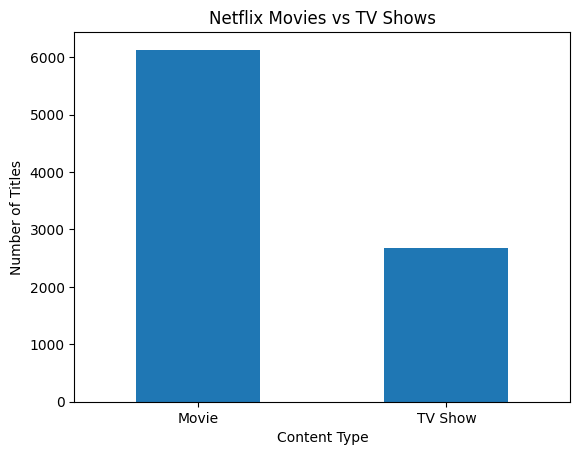

In [ ]:
## 6. Data Visualizations
import matplotlib.pyplot as plt

type_counts = clean_df["type"].value_counts()

type_counts.plot(kind="bar")

plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()

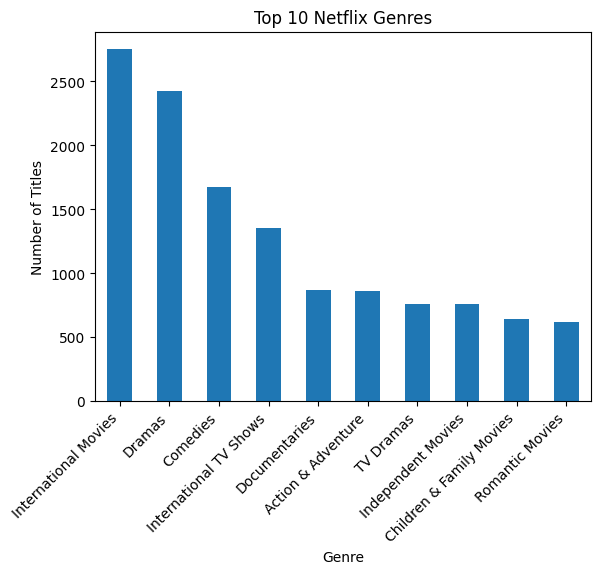

In [ ]:
top_genres = all_genres.value_counts().head(10)

top_genres.plot(kind="bar")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()

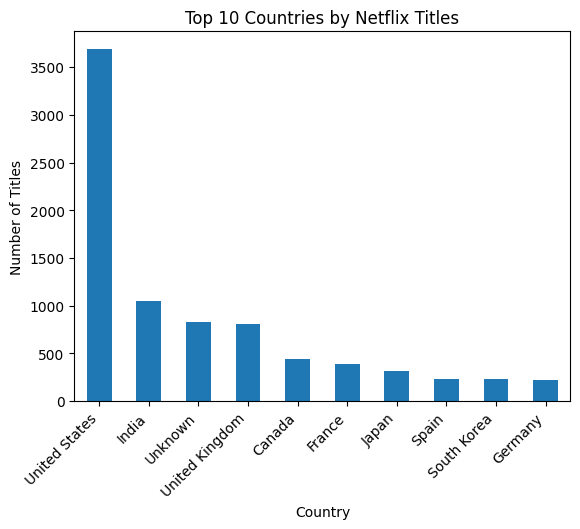

In [ ]:
top_countries = all_countries.value_counts().head(10)

top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()

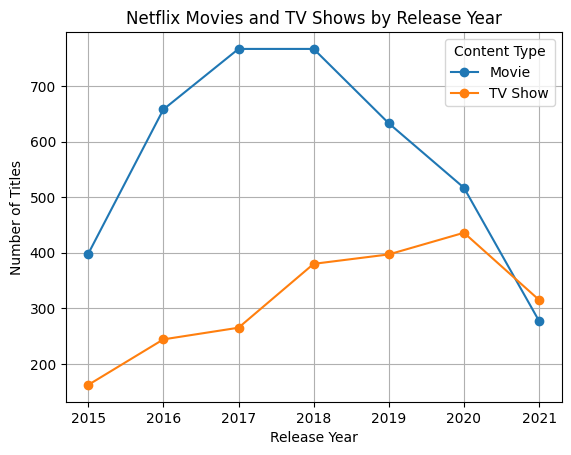

In [ ]:
recent_year_type.plot(kind="line", marker="o")

plt.title("Netflix Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.grid()
plt.show()

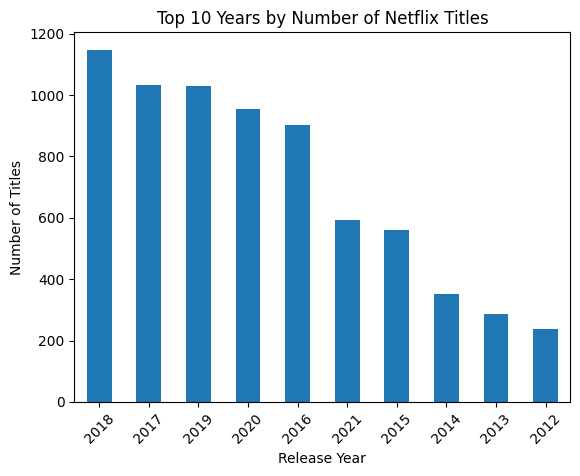

In [ ]:
top_years = clean_df["release_year"].value_counts().head(10)

top_years.plot(kind="bar")

plt.title("Top 10 Years by Number of Netflix Titles")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

In [ ]:
rating_counts = clean_df["rating"].value_counts()
rating_counts

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [ ]:
rating_percentage = (
    clean_df["rating"].value_counts(normalize=True) * 100
).round(2)

rating_percentage

,proportion
rating,
TV-MA,36.41
TV-14,24.53
TV-PG,9.80
R,9.07
PG-13,5.56
TV-Y7,3.79
TV-Y,3.49
PG,3.26
TV-G,2.50


In [ ]:
rating_summary = pd.DataFrame({
    "Count": clean_df["rating"].value_counts(),
    "Percentage": rating_percentage
})

rating_summary

,Count,Percentage
rating,,
TV-MA,3207,36.41
TV-14,2160,24.53
TV-PG,863,9.80
R,799,9.07
PG-13,490,5.56
TV-Y7,334,3.79
TV-Y,307,3.49
PG,287,3.26
TV-G,220,2.50


In [ ]:
clean_df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [ ]:
clean_df["release_year"].describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Netflix Movies and TV Shows Data Analysis

## Project Overview

This project analyzes the Netflix Movies and TV Shows dataset using Python and Pandas.

The goal is to understand Netflix's content distribution, genres, countries, ratings, release trends, directors, actors, and the differences between Movies and TV Shows.

## 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

df = pd.read_csv("/content/netflix_titles.csv")
df.head()

## 3. Understanding the Dataset

df.shape
df.columns
df.info()
df.describe()
df.isna().sum()

## 4. Data Cleaning

df.duplicated().sum()
clean_df = df.copy()

clean_df["director"] = clean_df["director"].fillna("Unknown")
clean_df["cast"] = clean_df["cast"].fillna("Unknown")
clean_df["country"] = clean_df["country"].fillna("Unknown")
clean_df["date_added"] = clean_df["date_added"].fillna("Unknown")
clean_df["rating"] = clean_df["rating"].fillna("Unknown")

clean_df.isna().sum()

## 5. Exploratory Data Analysis

clean_df["type"].value_counts()
(clean_df["type"].value_counts(normalize=True) * 100).round(2)

5.2 Top 10 Genres

genres = clean_df["listed_in"].str.split(", ")
all_genres = genres.explode()

top_genres = all_genres.value_counts().head(10)
top_genres

5.3 Top 10 Countries

countries = clean_df["country"].str.split(", ")
all_countries = countries.explode()

top_countries = all_countries.value_counts().head(10)
top_countries

5.4 Release Year Analysis
clean_df["release_year"].value_counts().sort_index()

Top years:

clean_df["release_year"].value_counts().head(10)
5.5 Movies vs TV Shows by Year

year_type = clean_df.groupby(
    ["release_year", "type"]
).size().unstack(fill_value=0)

year_type.tail(10)
5.6 Ratings
rating_summary = clean_df["rating"].value_counts()
rating_summary.head(10)
5.7 Top Directors
directors = clean_df["director"].str.split(", ")
all_directors = directors.explode()

top_directors = (
    all_directors[all_directors != "Unknown"]
    .value_counts()
    .head(10)
)

top_directors
5.8 Top Actors
actors = clean_df["cast"].str.split(", ")
all_actors = actors.explode()

top_actors = (
    all_actors[all_actors != "Unknown"]
    .value_counts()
    .head(10)
)





## 6. Data Visualizations
Chart 1 — Movies vs TV Shows
clean_df["type"].value_counts().plot(kind="bar")

plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.show()
Chart 2 — Top Genres
top_genres.plot(kind="bar")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()
Chart 3 — Top Countries
top_countries.plot(kind="bar")

plt.title("Top 10 Countries by Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.show()
Chart 4 — Yearly Trend
year_type.plot(kind="line", marker="o")

plt.title("Netflix Movies and TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Content Type")
plt.grid()
plt.show()





## 7. Key Insights

* The dataset contains **8,807 Netflix titles**, including **6,131 Movies** and **2,676 TV Shows**.
* Movies make up approximately **69.63%** of the Netflix catalog, while TV Shows account for approximately **30.37%**.
* **International Movies** are the most common genre category, with **2,752 titles**, followed by **Dramas (2,427)** and **Comedies (1,674)**.
* The **United States** is the largest contributor of Netflix titles in the dataset, with **3,689 titles**, followed by **India (1,046)** and the **United Kingdom (804)**.
* **TV-MA** is the most common content rating, with **3,207 titles**, followed by **TV-14 (2,160)** and **TV-PG (863)**.
* **2018** has the highest number of titles by release year, with **1,147 titles**, followed by **2017 (1,032)** and **2019 (1,030)**.
* The dataset shows that Netflix has a diverse content library covering many countries, genres, ratings, and release years.


## 8. Conclusion

This project analyzed the Netflix Movies and TV Shows dataset using Python, Pandas, and Matplotlib.

The analysis examined **8,807 Netflix titles** and explored important aspects of the content library, including Movies and TV Shows, genres, countries, release years, ratings, directors, and actors.

Data cleaning techniques were used to handle missing values and prepare the dataset for analysis. Pandas techniques such as filtering, grouping, aggregation, string splitting, `explode()`, and data transformation were used to extract meaningful information from the dataset.

The analysis showed that Movies make up the majority of the Netflix catalog, while International Movies, Dramas, and Comedies are among the most common categories. The United States is the largest contributor of titles in the dataset, and TV-MA is the most common content rating.

Overall, this project demonstrates practical skills in **data cleaning, exploratory data analysis, data manipulation, and visualization using Pandas and Matplotlib**.


In [ ]:
print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv_shows)

print("\nTop 5 Genres:")
print(all_genres.value_counts().head(5))

print("\nTop 5 Countries:")
print(all_countries.value_counts().head(5))

print("\nTop 5 Ratings:")
print(clean_df["rating"].value_counts().head(5))

print("\nTop 5 Release Years:")
print(clean_df["release_year"].value_counts().head(5))

Total Titles: 8807
Total Movies: 6131
Total TV Shows: 2676

Top 5 Genres:
listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1351
Documentaries              869
Name: count, dtype: int64

Top 5 Countries:
country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64

Top 5 Ratings:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64

Top 5 Release Years:
release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
Name: count, dtype: int64
